# Waymo Crashes Data

**Author**: Diego Torrealba

**Date Created**: 2026-06-23
**Date Last Modified**: 2026-06-23

Read about where I found the data in the README. 

## Import libraries and download data

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt

In [117]:
# rename helper function
def snake_case_rename(df) -> pd.DataFrame: 
  df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
  return df

In [ ]:
ro_mi_per_location: pd.DataFrame = pd.read_csv("../data/raw/csv1-RO-Miles-per-Location.csv")
ro_mi_per_location = ro_mi_per_location[ro_mi_per_location['County Name'] != "All Locations (mileage blended)"] # get rid of aggregate row

crashes_w_sgo_id_and_group_membership: pd.DataFrame = pd.read_csv("../data/raw/csv2-Crashes-with-SGO-ID-and-Group-Membership.csv")

collision_counts_and_comparison_to_benchmarks: pd.DataFrame = pd.read_csv("../data/raw/csv3-Collision-Counts-and-Comparison-to-Benchmarks.csv")

mi_and_benchmark_crashes_for_dynamic_benchmark: pd.DataFrame = pd.read_csv("../data/raw/csv4-Miles-and-Benchmark-Crashes-for-Dynamic-Benchmark.csv")

Mapping county to state names

In [78]:
ro_mi_per_location['County Name'].values.tolist()

['San Mateo',
 'San Francisco',
 'San Francisco Bay Area',
 'Maricopa',
 'Santa Clara',
 'Los Angeles',
 'Travis']

In [ ]:
county_to_states: dict[str, str] = {
    'San Mateo': 'California',
    'San Francisco': 'California',
    'San Francisco Bay Area': 'California',
    'Maricopa': 'Arizona',
    'Santa Clara': 'California',
    'Los Angeles': 'California',
    'Travis': 'Texas'
}

### RO-Miles-per-Location 

In [80]:
ro_mi_per_location["state_name"] = ro_mi_per_location["County Name"].map(county_to_states)

ro_mi_per_location_og = ro_mi_per_location[["County Name", "state_name", "Waymo RO Miles (Millions)"]].sort_values("Waymo RO Miles (Millions)", ascending=False).rename({"County Name": "county_name", "Waymo RO Miles (Millions)": "waymo_ro_miles"}, axis=1)

ro_mi_per_location["waymo_ro_miles"] = ro_mi_per_location_og["waymo_ro_miles"] * 1000000
ro_mi_per_location.sort_values('waymo_ro_miles', ascending=False)

,County Name,Waymo RO Miles (Millions),state_name,waymo_ro_miles
4,Maricopa,68.613,Arizona,68613000.0
2,San Francisco Bay Area,53.520,California,53520000.0
1,San Francisco,47.906,California,47906000.0
6,Los Angeles,37.857,California,37857000.0
7,Travis,10.722,Texas,10722000.0
0,San Mateo,3.061,California,3061000.0
5,Santa Clara,2.554,California,2554000.0


In [81]:
ro_mi_per_location.shape

(7, 4)

In [82]:
ro_mi_per_location.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 0 to 7
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   County Name                7 non-null      str    
 1   Waymo RO Miles (Millions)  7 non-null      float64
 2   state_name                 7 non-null      str    
 3   waymo_ro_miles             7 non-null      float64
dtypes: float64(2), str(2)
memory usage: 424.0 bytes


### Crashes-with-SGO-ID-and-Group-Membership

In [83]:
crashes_w_sgo_id_and_group_membership.head(5)

,SGO Report ID,SGO Report Version,SGO Amendment,Year Month,State,County,Road Type,Crash Type,Is NHTSA Reportable In-Transport,Is NHTSA Reportable In-Transport Delta-V Less than 1 MPH,Is Police-Reported,Is Any-Injury-Reported,Is Any Vehicle Airbag Deployment,Is Ego Vehicle Airbag Deployment,Is Suspected Serious Injury+,Is Any Fatal Injury,Incident Date,Location Address / Description,Zip Code
0,30270-13564,1.0,Amendment 3,202512,California,San Francisco,Surface Street,Cyclist,True,False,False,False,False,False,False,False,12/28/2025,Polk Street at Pacific Avenue,94109
1,30270-13557,1.0,Amendment 3,202512,Georgia,Fulton,Surface Street,V2V Backing,True,False,False,False,False,False,False,False,12/31/2025,Armour Drive NE near Plasters Avenue,30324
2,30270-13554,1.0,Amendment 3,202512,California,San Mateo,Surface Street,V2V F2R,True,False,False,False,False,False,False,False,12/29/2025,Airport Boulevard near Grand Avenue,94080
3,30270-13549,1.0,Amendment 3,202512,California,Los Angeles,Surface Street,V2V F2R,True,False,False,False,False,False,False,False,12/29/2025,Montana Avenue at S. Barrington Avenue,90049
4,30270-13548,1.0,Amendment 3,202512,Arizona,Maricopa,Surface Street,V2V Lateral,True,False,False,False,False,False,False,False,12/24/2025,N. 56th Street at E. Lafayette Boulevard,85018


In [84]:
crashes_w_sgo_id_and_group_membership.shape

(1390, 19)

In [85]:
crashes_w_sgo_id_and_group_membership.info()

<class 'pandas.DataFrame'>
RangeIndex: 1390 entries, 0 to 1389
Data columns (total 19 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   SGO Report ID                                             1388 non-null   str    
 1   SGO Report Version                                        1388 non-null   float64
 2   SGO Amendment                                             1390 non-null   str    
 3   Year Month                                                1390 non-null   int64  
 4   State                                                     1390 non-null   str    
 5   County                                                    1390 non-null   str    
 6   Road Type                                                 1390 non-null   str    
 7   Crash Type                                                1390 non-null   str    
 8   Is NHTSA Reportable In-Transp

In [86]:
crashes_w_sgo_id_and_group_membership = snake_case_rename(crashes_w_sgo_id_and_group_membership)
crashes_w_sgo_id_and_group_membership['year_month'] = pd.to_datetime(crashes_w_sgo_id_and_group_membership['year_month'], format="%Y%m")
crashes_w_sgo_id_and_group_membership['year'] = crashes_w_sgo_id_and_group_membership['year_month'].dt.year
crashes_w_sgo_id_and_group_membership['month'] = crashes_w_sgo_id_and_group_membership['year_month'].dt.month
crashes_w_sgo_id_and_group_membership['month_name'] = crashes_w_sgo_id_and_group_membership['year_month'].dt.month_name()
crashes_w_sgo_id_and_group_membership['month_year_str'] = crashes_w_sgo_id_and_group_membership['month_name'].str.strip() + " " + crashes_w_sgo_id_and_group_membership['year'].astype('str')
crashes_w_sgo_id_and_group_membership = crashes_w_sgo_id_and_group_membership[[
 'sgo_report_id',
 'sgo_report_version',
 'sgo_amendment',
 'year_month',
 'year',
 'month',
 'month_name',
 'month_year_str',
 'state',
 'county',
 'road_type',
 'crash_type',
 'is_nhtsa_reportable_in-transport',
 'is_nhtsa_reportable_in-transport_delta-v_less_than_1_mph',
 'is_police-reported',
 'is_any-injury-reported',
 'is_any_vehicle_airbag_deployment',
 'is_ego_vehicle_airbag_deployment',
 'is_suspected_serious_injury+',
 'is_any_fatal_injury',
 'incident_date',
 'location_address_/_description',
 'zip_code'
]]

In [87]:
crashes_w_sgo_id_and_group_membership[['month_year_str']]

,month_year_str
0,December 2025
1,December 2025
2,December 2025
3,December 2025
4,December 2025
...,...
1385,October 2021
1386,October 2021
1387,September 2021
1388,May 2021


In [88]:
crashes_w_sgo_id_and_group_membership[['year']].value_counts().reset_index()

,year,count
0,2025,867
1,2024,429
2,2023,85
3,2022,4
4,2021,4
5,2020,1


Getting rid of reports for the same crashes

In [89]:
ids_w_version_2_reports = crashes_w_sgo_id_and_group_membership[crashes_w_sgo_id_and_group_membership['sgo_report_version'] == 2.0]['sgo_report_id'].unique().tolist()

sgo_id_counts =crashes_w_sgo_id_and_group_membership['sgo_report_id'].value_counts().reset_index(name='count')
sgo_id_reports_with_multiple_versions = sgo_id_counts[sgo_id_counts['count'] > 1]['sgo_report_id'].tolist()

crashes_w_sgo_id_and_group_membership.drop_duplicates(subset=['sgo_report_id', 'sgo_report_version'], keep='last', inplace=True)

# crashes_w_sgo_id_and_group_membership[crashes_w_sgo_id_and_group_membership['sgo_report_id'].isin(sgo_id_reports_with_multiple_versions)].sort_values(['sgo_report_id', 'sgo_report_version'], ascending=[True, True])

### Collision-Counts-and-Comparison-to-Benchmarks

In [90]:
collision_counts_and_comparison_to_benchmarks.head(5)

,Outcome,Benchmark Comparison,County Name,Grouping Type,Conflict Partner Type Group,Waymo Count,Delta V Less Than 1 Mph Percent,Waymo IPMM,Waymo IPMM CI Lower,Waymo IPMM CI Upper,...,Benchmark IPMM CI Lower,Benchmark IPMM CI Upper,Predicted Benchmark Count,Waymo Count Reduction,Waymo Percent Reduction,Waymo Percent Reduction CI Lower,Waymo Percent Reduction CI Upper,Waymo Rate Ratio,Waymo Rate Ratio CI Lower,Waymo Rate Ratio CI Upper
0,Any Airbag Deployment,Any Airbag Deployment (non-Dynamic),All Locations (mileage blended),All Crashes,All Crashes,48,0.020833,0.281175,0.207316,0.372797,...,1.419534,1.455020,245.346833,197.346833,-0.804359,-0.862165,-0.730851,0.195641,0.137835,0.269149
1,Any Airbag Deployment,Any Airbag Deployment (non-Dynamic),Los Angeles,All Crashes,All Crashes,8,0.000000,0.211319,0.091233,0.416383,...,1.153177,1.177662,44.117927,36.117927,-0.818668,-0.931393,-0.614316,0.181332,0.068607,0.385684
2,Any Airbag Deployment,Any Airbag Deployment (non-Dynamic),Maricopa,All Crashes,All Crashes,19,0.000000,0.276914,0.166720,0.432436,...,1.306042,1.334647,90.589193,71.589193,-0.790262,-0.883088,-0.654062,0.209738,0.116912,0.345938
3,Any Airbag Deployment,Any Airbag Deployment (non-Dynamic),San Francisco,All Crashes,All Crashes,13,0.076923,0.271367,0.144492,0.464047,...,1.698358,1.878033,85.583291,72.583291,-0.848101,-0.926766,-0.722260,0.151899,0.073234,0.277740
4,Any Airbag Deployment,Any Airbag Deployment (non-Dynamic),San Francisco Bay Area,All Crashes,All Crashes,17,0.058824,0.317640,0.185037,0.508572,...,1.631041,1.790858,91.494635,74.494635,-0.814197,-0.900551,-0.684008,0.185803,0.099449,0.315992


In [91]:
collision_counts_and_comparison_to_benchmarks.shape

(1092, 21)

In [92]:
collision_counts_and_comparison_to_benchmarks.info()

<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Outcome                           1092 non-null   str    
 1   Benchmark Comparison              1092 non-null   str    
 2   County Name                       1092 non-null   str    
 3   Grouping Type                     1092 non-null   str    
 4   Conflict Partner Type Group       1092 non-null   str    
 5   Waymo Count                       1092 non-null   int64  
 6   Delta V Less Than 1 Mph Percent   518 non-null    float64
 7   Waymo IPMM                        1092 non-null   float64
 8   Waymo IPMM CI Lower               1092 non-null   float64
 9   Waymo IPMM CI Upper               1092 non-null   float64
 10  Benchmark IPMM                    1092 non-null   float64
 11  Benchmark IPMM CI Lower           1092 non-null   float64
 12  Benchmark IPMM CI

In [93]:
collision_counts_and_comparison_to_benchmarks = snake_case_rename(collision_counts_and_comparison_to_benchmarks)
collision_counts_and_comparison_to_benchmarks.columns

Index(['outcome', 'benchmark_comparison', 'county_name', 'grouping_type',
       'conflict_partner_type_group', 'waymo_count',
       'delta_v_less_than_1_mph_percent', 'waymo_ipmm', 'waymo_ipmm_ci_lower',
       'waymo_ipmm_ci_upper', 'benchmark_ipmm', 'benchmark_ipmm_ci_lower',
       'benchmark_ipmm_ci_upper', 'predicted_benchmark_count',
       'waymo_count_reduction', 'waymo_percent_reduction',
       'waymo_percent_reduction_ci_lower', 'waymo_percent_reduction_ci_upper',
       'waymo_rate_ratio', 'waymo_rate_ratio_ci_lower',
       'waymo_rate_ratio_ci_upper'],
      dtype='str')

### Miles-and-Benchmark-Crashes-for-Dynamic-Benchmark

In [94]:
mi_and_benchmark_crashes_for_dynamic_benchmark.head(5)

,state_name,county_name,S2 Cell,Outcome,Benchmark Crash Count,HPMS Yearly Vehicle Miles Traveled,Waymo RO Miles
0,Arizona,Maricopa,9739878636298698752,police_reported,24.769229,8.360097e+06,3171.852611
1,Arizona,Maricopa,9739878636298698752,blincoe,49.462419,8.360097e+06,3171.852611
2,Arizona,Maricopa,9739878636298698752,fatal,0.000000,8.360097e+06,3171.852611
3,Arizona,Maricopa,9739878636298698752,ka,4.846153,8.360097e+06,3171.852611
4,Arizona,Maricopa,9739878636298698752,ego_airbag,11.846153,8.360097e+06,3171.852611


In [95]:
mi_and_benchmark_crashes_for_dynamic_benchmark.shape

(14736, 7)

In [96]:
mi_and_benchmark_crashes_for_dynamic_benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 14736 entries, 0 to 14735
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   state_name                          14736 non-null  str    
 1   county_name                         14736 non-null  str    
 2   S2 Cell                             14736 non-null  uint64 
 3   Outcome                             14736 non-null  str    
 4   Benchmark Crash Count               14736 non-null  float64
 5   HPMS Yearly Vehicle Miles Traveled  14736 non-null  float64
 6   Waymo RO Miles                      14736 non-null  float64
dtypes: float64(3), str(3), uint64(1)
memory usage: 1.2 MB


In [97]:
mi_and_benchmark_crashes_for_dynamic_benchmark = snake_case_rename(mi_and_benchmark_crashes_for_dynamic_benchmark)
mi_and_benchmark_crashes_for_dynamic_benchmark.columns

Index(['state_name', 'county_name', 's2_cell', 'outcome',
       'benchmark_crash_count', 'hpms_yearly_vehicle_miles_traveled',
       'waymo_ro_miles'],
      dtype='str')

In [98]:
mi_and_benchmark_crashes_for_dynamic_benchmark[['s2_cell', 'outcome']]

,s2_cell,outcome
0,9739878636298698752,police_reported
1,9739878636298698752,blincoe
2,9739878636298698752,fatal
3,9739878636298698752,ka
4,9739878636298698752,ego_airbag
...,...,...
14731,9278198789036834816,police_reported
14732,9278198789036834816,fatal
14733,9278198789036834816,airbag
14734,9278198789036834816,blincoe


## Looking at Travis County, TX

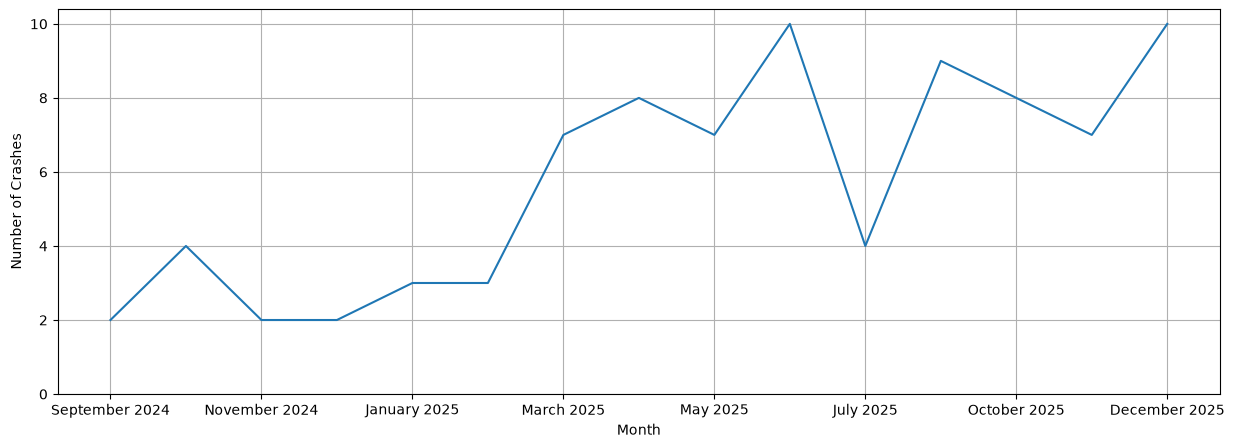

In [99]:
travis_crashes_w_sgo_id_and_group = crashes_w_sgo_id_and_group_membership[crashes_w_sgo_id_and_group_membership['county'] == "Travis"]
travis_crashes_w_sgo_id_and_group[['month_year_str', 'year_month']].value_counts().reset_index().sort_values('year_month', ascending=True).plot(x = 'month_year_str', y = 'count', kind="line", figsize=(15, 5), xlabel="Month", ylabel = "Number of Crashes", legend=False, grid=True, ylim = 0)
plt.show()

In [100]:
travis_crashes_w_sgo_id_and_group[["year_month", "month_year_str", 'is_any-injury-reported']].groupby(['year_month', 'month_year_str']).agg('sum').reset_index()

,year_month,month_year_str,is_any-injury-reported
0,2024-09-01,September 2024,0
1,2024-10-01,October 2024,0
2,2024-11-01,November 2024,0
3,2024-12-01,December 2024,0
4,2025-01-01,January 2025,0
5,2025-02-01,February 2025,0
6,2025-03-01,March 2025,1
7,2025-04-01,April 2025,0
8,2025-05-01,May 2025,1
9,2025-06-01,June 2025,1


In [101]:
travis_crashes_w_sgo_id_and_group.columns

Index(['sgo_report_id', 'sgo_report_version', 'sgo_amendment', 'year_month',
       'year', 'month', 'month_name', 'month_year_str', 'state', 'county',
       'road_type', 'crash_type', 'is_nhtsa_reportable_in-transport',
       'is_nhtsa_reportable_in-transport_delta-v_less_than_1_mph',
       'is_police-reported', 'is_any-injury-reported',
       'is_any_vehicle_airbag_deployment', 'is_ego_vehicle_airbag_deployment',
       'is_suspected_serious_injury+', 'is_any_fatal_injury', 'incident_date',
       'location_address_/_description', 'zip_code'],
      dtype='str')

In [102]:
travis_crashes_w_sgo_id_and_group.groupby(['year_month', 'month_year_str'])['is_any_fatal_injury'].sum().reset_index()

,year_month,month_year_str,is_any_fatal_injury
0,2024-09-01,September 2024,0
1,2024-10-01,October 2024,0
2,2024-11-01,November 2024,0
3,2024-12-01,December 2024,0
4,2025-01-01,January 2025,0
5,2025-02-01,February 2025,0
6,2025-03-01,March 2025,0
7,2025-04-01,April 2025,0
8,2025-05-01,May 2025,0
9,2025-06-01,June 2025,0


In [103]:
zip_to_neighborhood = {
    "78701": "Downtown Austin",
    "78702": "East Austin",
    "78703": "Tarrytown / Clarksville",
    "78704": "South Congress / Bouldin Creek",
    "78705": "UT Campus / Hyde Park",
    "78712": "UT Austin (Campus Core)",
    "78722": "Cherrywood / MLK",
    "78723": "Mueller / Windsor Park",
    "78724": "Colony Park / Montopolis",
    "78741": "Riverside / East Riverside",
    "78744": "Southeast Austin / Dove Springs",
    "78745": "South Austin / Slaughter Lane",
    "78746": "West Lake Hills / Rollingwood",
    "78751": "Hyde Park / North Loop",
    "78752": "North Loop / Rundberg",
    "78757": "Crestview / Brentwood",
    "78778": "State Agency Zone (non-residential)",
}

travis_crashes_w_sgo_id_and_group['neighborhood'] = travis_crashes_w_sgo_id_and_group['zip_code'].map(zip_to_neighborhood)
travis_neighborhoods_any_injuries = travis_crashes_w_sgo_id_and_group.groupby(['neighborhood'])['is_any-injury-reported'].sum().reset_index()
travis_neighborhoods_any_injuries = travis_neighborhoods_any_injuries[travis_neighborhoods_any_injuries['is_any-injury-reported'] > 0]


travis_neighborhoods_any_injuries

,neighborhood,is_any-injury-reported
3,East Austin,1
4,Hyde Park / North Loop,1
9,South Congress / Bouldin Creek,2
14,UT Campus / Hyde Park,1


In [104]:
crash_type_counts = travis_crashes_w_sgo_id_and_group['crash_type'].value_counts().reset_index()
crash_type_counts

,crash_type,count
0,V2V Lateral,21
1,V2V F2R,18
2,V2V Backing,14
3,V2V Intersection,9
4,Single Vehicle,8
5,All Others,8
6,V2V Head-on,7
7,Secondary Crash,1


In [105]:
travis_crashes_w_sgo_id_and_group.groupby(['crash_type'])['is_any-injury-reported'].sum().reset_index().sort_values('is_any-injury-reported', ascending=False)

,crash_type,is_any-injury-reported
4,V2V F2R,3
0,All Others,1
5,V2V Head-on,1
6,V2V Intersection,1
7,V2V Lateral,1
1,Secondary Crash,0
2,Single Vehicle,0
3,V2V Backing,0


In [106]:
travis_crashes_w_sgo_id_and_group.incident_date = pd.to_datetime(travis_crashes_w_sgo_id_and_group.incident_date, format="%m/%d/%Y")
travis_crashes_w_sgo_id_and_group['incident_date_yr_mo'] = travis_crashes_w_sgo_id_and_group['incident_date'].dt.to_period("M")

travis_crashes_by_yr_month = travis_crashes_w_sgo_id_and_group.groupby([travis_crashes_w_sgo_id_and_group['incident_date_yr_mo']]).agg({'sgo_report_id': 'count', 'is_police-reported': 'sum'}).reset_index().rename({"sgo_report_id": "crash_total", "is_police-reported": "police_reported_crashes"}, axis=1)


travis_crashes_by_yr_month['incident_date'] = pd.to_datetime(travis_crashes_by_yr_month['incident_date_yr_mo'].astype(str))

travis_crashes_by_yr_month = travis_crashes_by_yr_month[["incident_date", "crash_total", "police_reported_crashes"]]

travis_crashes_by_yr_month = pd.melt(travis_crashes_by_yr_month, id_vars=['incident_date'], value_vars=['crash_total', 'police_reported_crashes'], var_name="parameter", value_name = "value")

travis_crashes_by_yr_month.loc[travis_crashes_by_yr_month['parameter'] == 'crash_total', 'parameter'] = "Total Crashes"
travis_crashes_by_yr_month.loc[travis_crashes_by_yr_month['parameter'] == 'police_reported_crashes', 'parameter'] = "Police-Reported Crashes"

travis_crashes_by_yr_month

,incident_date,parameter,value
0,2024-09-01,Total Crashes,2
1,2024-10-01,Total Crashes,4
2,2024-11-01,Total Crashes,2
3,2024-12-01,Total Crashes,2
4,2025-01-01,Total Crashes,3
5,2025-02-01,Total Crashes,3
6,2025-03-01,Total Crashes,7
7,2025-04-01,Total Crashes,8
8,2025-05-01,Total Crashes,7
9,2025-06-01,Total Crashes,10


In [109]:
tx_crashes_w_police_reported_crashes_line_chart = alt.Chart(travis_crashes_by_yr_month).mark_line(point=True).encode(
  x = alt.X("incident_date:T", title = "Incident Month"),
  y = alt.Y("value:Q", title = "Number of Crashes"),
  color = alt.Color("parameter:N", legend=alt.Legend(title="Parameter"), sort="ascending"),
).properties(
  title = "Travis County Crashes Over Time",
  width = 500
)

tx_crashes_w_police_reported_crashes_line_chart

alt.Chart(...)

### Waymo crashes by Travis County neighborhoods

We need to get Travis County zipcodes

In [114]:
import requests, json, geopandas as gpd

In [115]:
travis_county_zipcodes_url: str = "https://gis.traviscountytx.gov/server1/rest/services/Boundaries_and_Jurisdictions/ZIP_Codes/MapServer/0/query"
url_params: dict[str: str] = {
  "where": "1=1",
  "outFields": "*",
  "outSR": "4326",
  "f": "geojson"
}

get_request: requests.Response = requests.get(travis_county_zipcodes_url, params=url_params)
with open("../data/travis_zipcodes.geojson", "w") as f:
  json.dump(get_request.json(), f)
  
austin_zipcodes: gpd.GeoDataFrame = gpd.read_file("../data/travis_zipcodes.geojson")

In [ ]:
austin_zipcodes = snake_case_rename(austin_zipcodes)
austin_zipcodes = austin_zipcodes[["zip_code", "geometry"]]

In [123]:
austin_zipcodes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   zip_code  63 non-null     str     
 1   geometry  63 non-null     geometry
dtypes: geometry(1), str(1)
memory usage: 1.4 KB


In [125]:
travis_crashes_w_sgo_id_and_group.zip_code.info()

<class 'pandas.Series'>
Index: 86 entries, 10 to 1089
Series name: zip_code
Non-Null Count  Dtype
--------------  -----
86 non-null     str  
dtypes: str(1)
memory usage: 1.7 KB


In [132]:
travis_crashes_w_zipcodes = travis_crashes_w_sgo_id_and_group.merge(austin_zipcodes, on="zip_code", how="left")
travis_crashes_w_zipcodes[travis_crashes_w_zipcodes['geometry'].isnull() == True]

,sgo_report_id,sgo_report_version,sgo_amendment,year_month,year,month,month_name,month_year_str,state,county,...,is_any_vehicle_airbag_deployment,is_ego_vehicle_airbag_deployment,is_suspected_serious_injury+,is_any_fatal_injury,incident_date,location_address_/_description,zip_code,neighborhood,incident_date_yr_mo,geometry
32,30270-11623,1.0,Amendment 3,2025-09-01,2025,9,September,September 2025,Texas,Travis,...,False,False,False,False,2025-09-05,N. Interstate 35 Frontage Road near Woodward S...,,NaN,2025-09,None
33,30270-11612,1.0,Amendment 3,2025-09-01,2025,9,September,September 2025,Texas,Travis,...,False,False,False,False,2025-09-03,E. 8th Street at San Jacinto Boulevard,,NaN,2025-09,None
34,30270-11451,1.0,Amendment 3,2025-07-01,2025,7,July,July 2025,Texas,Travis,...,False,False,False,False,2025-07-29,E. 8th Street near Congress Avenue,,NaN,2025-07,None
35,30270-11371,1.0,Amendment 3,2025-07-01,2025,7,July,July 2025,Texas,Travis,...,False,False,False,False,2025-07-15,West Avenue at W. 6th Street,,NaN,2025-07,None
36,30270-11330,1.0,Amendment 3,2025-07-01,2025,7,July,July 2025,Texas,Travis,...,False,False,False,False,2025-07-13,Comal Street near E. 5th Street,,NaN,2025-07,None
37,30270-11328,1.0,Amendment 3,2025-07-01,2025,7,July,July 2025,Texas,Travis,...,False,False,False,False,2025-07-03,W. Cesar Chavez Street at Lavaca Street,,NaN,2025-07,None
38,30270-11291,1.0,Amendment 3,2025-06-01,2025,6,June,June 2025,Texas,Travis,...,False,False,False,False,2025-06-27,unnamed service road off E. Stassney Lane near...,,NaN,2025-06,None
39,30270-11247,1.0,Amendment 3,2025-06-01,2025,6,June,June 2025,Texas,Travis,...,False,False,False,False,2025-06-30,W. Monroe Street near S. 2nd Street,,NaN,2025-06,None
40,30270-11246,1.0,Amendment 3,2025-06-01,2025,6,June,June 2025,Texas,Travis,...,False,False,False,False,2025-06-30,Lavaca Street at W. 5th Street,,NaN,2025-06,None
41,30270-11238,1.0,Amendment 3,2025-06-01,2025,6,June,June 2025,Texas,Travis,...,False,False,False,False,2025-06-29,Douglas Street at E. Oltorf Street,,NaN,2025-06,None
